In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from time import time

# ML
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
import shap

# Chemistry
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

import warnings
warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

In [2]:
df = pd.read_csv(r'C:\Users\DELL\Desktop\P3\curated-solubility-dataset.csv')
df = df[['SMILES','Solubility']]
df.head()

,SMILES,Solubility
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,O=C1Nc2cccc3cccc1c23,-3.254767
2,Clc1ccc(C=O)cc1,-2.177078
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065


In [3]:
def full_clean(SMILES):
    mol = Chem.MolFromSmiles(SMILES)
    if mol is None: return None
    mol = rdMolStandardize.Cleanup(mol)
    mol = rdMolStandardize.FragmentParent(mol)
    mol = rdMolStandardize.Uncharger().uncharge(mol)
    allowed = {'H','C','N','O','S','P','F','Cl','Br','I'}
    if not {a.GetSymbol() for a in mol.GetAtoms()}.issubset(allowed):
        return None
    return Chem.MolToSmiles(mol)

In [4]:
df['clean_smiles'] = df['SMILES'].apply(full_clean)
print(f"Lost: {df['clean_smiles'].isna().sum()} / {len(df)}")
df = df.dropna(subset=['clean_smiles'])
df['mol'] = df['clean_smiles'].apply(Chem.MolFromSmiles)

Lost: 263 / 9982


In [5]:
df = df.dropna(subset=['mol']).reset_index(drop=True)
print(df['mol'].isna().sum()) 

0


In [6]:
def mol_to_fp(mol, fp_radius=2, nBits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, fp_radius, nBits=nBits)
    return np.array(fp)
x_fp = np.array([mol_to_fp(m) for m in df['mol']])

In [7]:
x_fp.shape

(9717, 2048)

In [8]:
desc_names = [d[0] for d in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)
desc_array = np.array([calc.CalcDescriptors(m) for m in df['mol']])

In [9]:
desc_df = pd.DataFrame(desc_array, columns=desc_names)
desc_df = desc_df.replace([np.inf, -np.inf], np.nan)
desc_df = desc_df.dropna(axis=1)
desc_df = desc_df.loc[:, desc_df.std() > 0]
corr = desc_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
desc_df = desc_df.drop(columns=to_drop)

In [10]:
desc_df.shape

(9717, 172)

In [11]:
x = np.hstack([desc_df.values, x_fp[:len(desc_df)]])
y = df['Solubility']

In [12]:
def get_scaffold(SMILES):
    mol = Chem.MolFromSmiles(SMILES)
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

df['scaffold'] = df['SMILES'].apply(get_scaffold)
print(f'{df["scaffold"].nunique()} unique scaffolds from {len(df)} molecules')

def scaffold_split(df, test_size=0.2):
    scaffolds = defaultdict(list)
    for i, smi in enumerate(df['SMILES']):
        mol = Chem.MolFromSmiles(smi)
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        scaffolds[Chem.MolToSmiles(scaffold)].append(i)
    
    scaffold_sets = sorted(scaffolds.values(), key=len, reverse=True)
    
    train_idx, test_idx = [], []
    for group in scaffold_sets:
        if len(train_idx) < len(df) * (1 - test_size):
          train_idx.extend(group)
        else:
          test_idx.extend(group)
    
    return train_idx, test_idx

2033 unique scaffolds from 9717 molecules


In [13]:
train_idx, test_idx = scaffold_split(df)
x_train_sc, x_test_sc = x[train_idx], x[test_idx]
y_train_sc, y_test_sc = y.iloc[train_idx], y.iloc[test_idx]
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train_sc)
x_test_sc = scaler.transform(x_test_sc)
x_train_sc = np.nan_to_num(x_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
x_test_sc = np.nan_to_num(x_test_sc, nan=0.0, posinf=0.0, neginf=0.0)
x_train_sc = np.clip(x_train_sc, -1e6, 1e6)
x_test_sc = np.clip(x_test_sc, -1e6, 1e6)

In [ ]:
'''
from sklearn.decomposition import PCA

pca = PCA().fit(x_train_sc)
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumvar)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.99, color='g', linestyle='--', label='99%')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.show()

print(f"95% variance: {np.argmax(cumvar >= 0.95) + 1} components")
print(f"99% variance: {np.argmax(cumvar >= 0.99) + 1} components") #dropping 25% of feasures not worth it
'''

'\nfrom sklearn.decomposition import PCA\n\npca = PCA().fit(x_train_sc)\ncumvar = np.cumsum(pca.explained_variance_ratio_)\n\nplt.plot(cumvar)\nplt.axhline(y=0.95, color=\'r\', linestyle=\'--\', label=\'95%\')\nplt.axhline(y=0.99, color=\'g\', linestyle=\'--\', label=\'99%\')\nplt.xlabel(\'Number of components\')\nplt.ylabel(\'Cumulative explained variance\')\nplt.legend()\nplt.show()\n\nprint(f"95% variance: {np.argmax(cumvar >= 0.95) + 1} components")\nprint(f"99% variance: {np.argmax(cumvar >= 0.99) + 1} components") #dropping 25% off feasures not worth it\n'


def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'verbose': -1,
        'n_jobs': -1,
    }
    model = LGBMRegressor(random_state=42)
    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,
                            scoring='neg_root_mean_squared_error').mean()
    return -score

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(study.best_params)
print(f"Best RMSE: {study.best_value:.4f}")
#{'n_estimators': 1275, 'learning_rate': 0.03654525490249624, 'num_leaves': 185, 'max_depth': 5, 'min_child_samples': 37, 'reg_alpha': 7.920501262742032, 'reg_lambda': 0.06058966674810814, 'subsample': 0.9024646526410958, 'colsample_bytree': 0.804337478311308} Best RMSE: 1.0164


def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'n_jobs': -1,
        'random_state': 42,
    }
    model = RandomForestRegressor(**params)
    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,
                            scoring='neg_root_mean_squared_error').mean()
    return -score

study_rf = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
)
study_rf.optimize(objective_rf, n_trials=20)

print(study_rf.best_params)
print(f"Best RMSE: {study_rf.best_value:.4f}")
#1.1563018235997025 and parameters: {'n_estimators': 526, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.3}. Best is trial 3 with value: 1.1563018235997025.

def objective_xg(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'n_jobs': -1,
        'random_state': 42,
    }
    model = XGBRegressor(**params)
    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,
                            scoring='neg_root_mean_squared_error').mean()
    return -score

study_xg = optuna.create_study(direction='minimize')
study_xg.optimize(objective_xg, n_trials=20)

print(study_xg.best_params)
print(f"Best RMSE: {study_xg.best_value:.4f}")
#{'n_estimators': 713, 'learning_rate': 0.10197460309843587, 'max_depth': 5, 'min_child_weight': 2, 'reg_alpha': 0.9632394455036623, 'reg_lambda': 2.3144590667079195, 'subsample': 0.6657809867263421, 'colsample_bytree': 0.6511573245590564, 'gamma': 0.5888383509072559} Best RMSE: 1.1089

In [15]:

best_lgbm_params = {
    'n_estimators': 1275,
    'learning_rate': 0.03654525490249624,
    'num_leaves': 185,
    'max_depth': 5,
    'min_child_samples': 37,
    'reg_alpha': 7.920501262742032,
    'reg_lambda': 0.06058966674810814,
    'subsample': 0.9024646526410958,
    'colsample_bytree': 0.804337478311308,
}

# Best XGB params (RMSE: 1.1089)
best_xgb_params = {
    'n_estimators': 713,
    'learning_rate': 0.10197460309843587,
    'max_depth': 5,
    'min_child_weight': 2,
    'reg_alpha': 0.9632394455036623,
    'reg_lambda': 2.3144590667079195,
    'subsample': 0.6657809867263421,
    'colsample_bytree': 0.6511573245590564,
    'gamma': 0.5888383509072559,
}

# Best RF params (RMSE: 1.1563)
best_rf_params = {
    'n_estimators': 526,
    'max_depth': 24,
    'min_samples_split': 12,
    'min_samples_leaf': 5,
    'max_features': 0.3,
}
models = {
    'lgbm': LGBMRegressor(**best_lgbm_params, random_state=42, verbose=-1, n_jobs=-1),
    'xgb': XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1),
    'rf': RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=4),
}

from time import time
for name, model in models.items():
    print(f"Training {name}...", end=" ", flush=True)
    t = time()
    model.fit(x_train_sc, y_train_sc)
    y_pred = model.predict(x_test_sc)
    print(f"RMSE: {root_mean_squared_error(y_test_sc, y_pred):.4f}  R²: {r2_score(y_test_sc, y_pred):.4f}  ({time()-t:.1f}s)")

Training lgbm... RMSE: 1.2560  R²: 0.6835  (13.5s)
Training xgb... RMSE: 1.2590  R²: 0.6820  (17.1s)
Training rf... RMSE: 1.2886  R²: 0.6669  (82.2s)


In [16]:
from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ('lgbm', LGBMRegressor(**best_lgbm_params, random_state=42, verbose=-1, n_jobs=-1)),
        ('xgb', XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1)),
        ('rf', RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=4)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=1
)

print("Training stack...", end=" ", flush=True)
t = time()
stack.fit(x_train_sc, y_train_sc)
y_pred = stack.predict(x_test_sc)
print(f"RMSE: {root_mean_squared_error(y_test_sc, y_pred):.4f}  R²: {r2_score(y_test_sc, y_pred):.4f}  ({time()-t:.1f}s)")

Training stack... RMSE: 1.2340  R²: 0.6945  (557.2s)


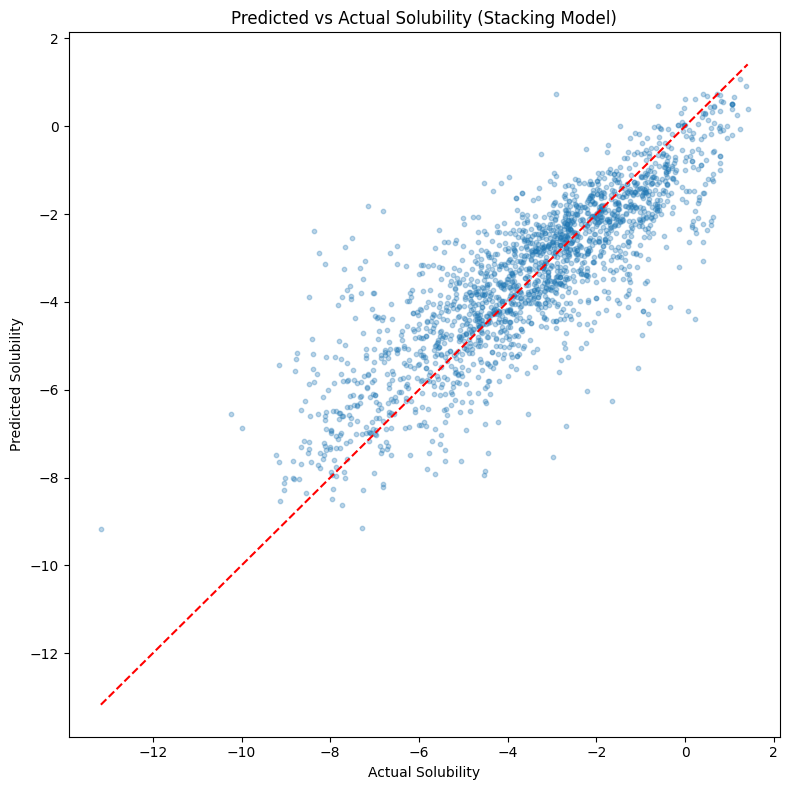

In [17]:
y_pred = stack.predict(x_test_sc)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_sc, y_pred, alpha=0.3, s=10)
plt.plot([y_test_sc.min(), y_test_sc.max()], [y_test_sc.min(), y_test_sc.max()], 'r--')
plt.xlabel('Actual Solubility')
plt.ylabel('Predicted Solubility')
plt.title('Predicted vs Actual Solubility (Stacking Model)')
plt.tight_layout()
plt.show()

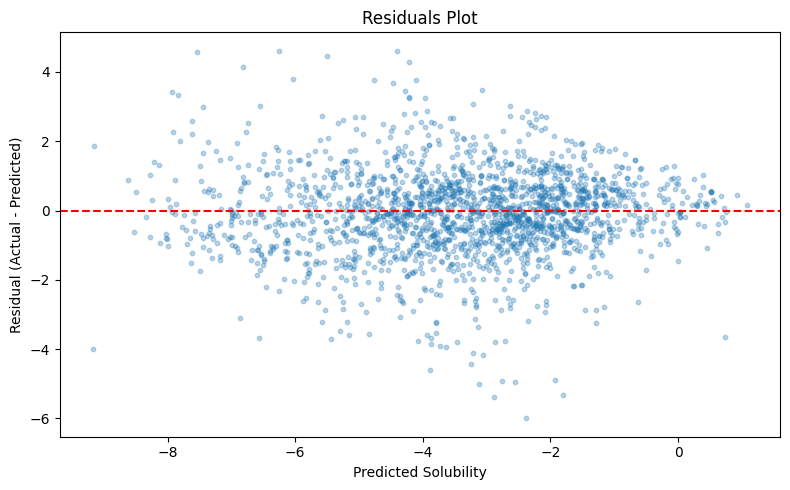

In [18]:
residuals = y_test_sc - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Solubility')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals Plot')
plt.tight_layout()
plt.show()

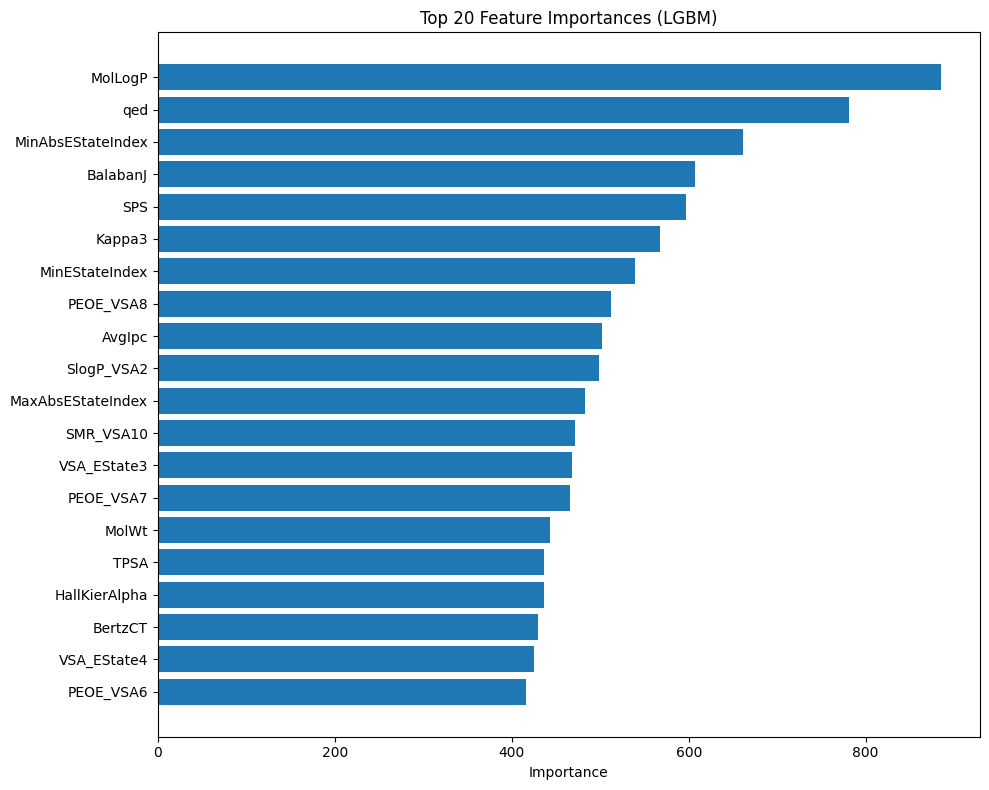

In [19]:
best_lgbm = LGBMRegressor(**best_lgbm_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(x_train_sc, y_train_sc)

feature_names = list(desc_df.columns) + [f'FP_{i}' for i in range(x_fp.shape[1])]
importances = best_lgbm.feature_importances_
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), [feature_names[i] for i in top_idx])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (LGBM)')
plt.tight_layout()
plt.show()

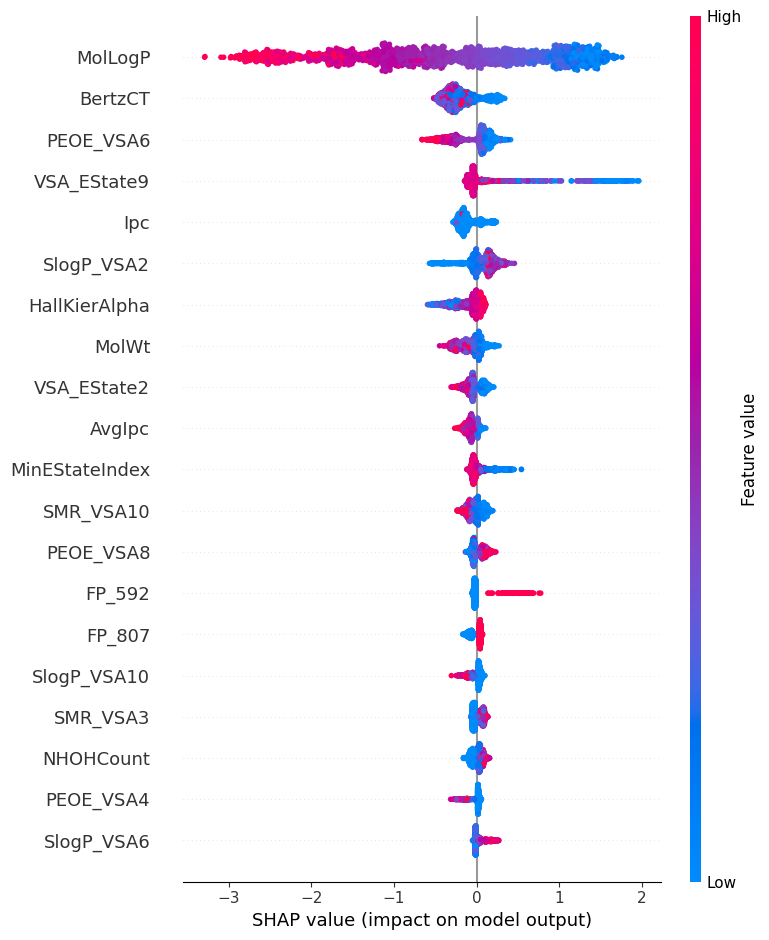

In [20]:
import shap

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(x_test_sc)

shap.summary_plot(shap_values, x_test_sc, 
                  feature_names=feature_names, 
                  max_display=20, 
                  show=True)

In [42]:
train_fps = [AllChem.GetMorganFingerprintAsBitVect(df['mol'].iloc[i], 2, 2048) for i in train_idx]

def ad_score(mol, train_fps):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    return max(sims)

def ad_tier(sim):
    if sim > 0.4: return "✅ in domain"
    if sim > 0.25: return "⚠️ low confidence"
    return "❌ out of domain"

def confidence_score_v2(mol, sim):
    bertz = Descriptors.BertzCT(mol)
    n_atoms = mol.GetNumHeavyAtoms()
    logp = Descriptors.MolLogP(mol)
    
    if n_atoms < 6 and logp < 0:
        return "🚨 Possibly miscible — model unreliable"
    
    score = 0
    if sim > 0.3: score += 1
    if sim > 0.6: score += 1
    if bertz < 800: score += 1
    if n_atoms > 5: score += 1
    
    labels = {4: "✅ High confidence",
              3: "🔶 Moderate confidence", 
              2: "⚠️ Low confidence",
              1: "❌ Unreliable",
              0: "❌ Unreliable"}
    
    return labels[score]

In [22]:
def predict_solubility(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return print("Invalid SMILES")
    
    # AD check
    sim = ad_score(mol, train_fps)
    
    # Fingerprint
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
    
    # Descriptors (same as training)
    desc_names_all = [d[0] for d in Descriptors._descList]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names_all)
    desc = np.array(calc.CalcDescriptors(mol))
    desc = pd.DataFrame([desc], columns=desc_names_all)
    desc = desc[desc_df.columns]
    
    # Combine + scale
    features = np.hstack([desc.values, fp.reshape(1, -1)])
    features = scaler.transform(features)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    features = np.clip(features, -1e6, 1e6)
    
    # Predict
    pred = stack.predict(features)[0]
    
    print(f"SMILES: {smiles}")
    print(f"Predicted Solubility: {pred:.2f} log(mol/L)")
    print(f"AD Score: {sim:.2f} — {ad_tier(sim)}")

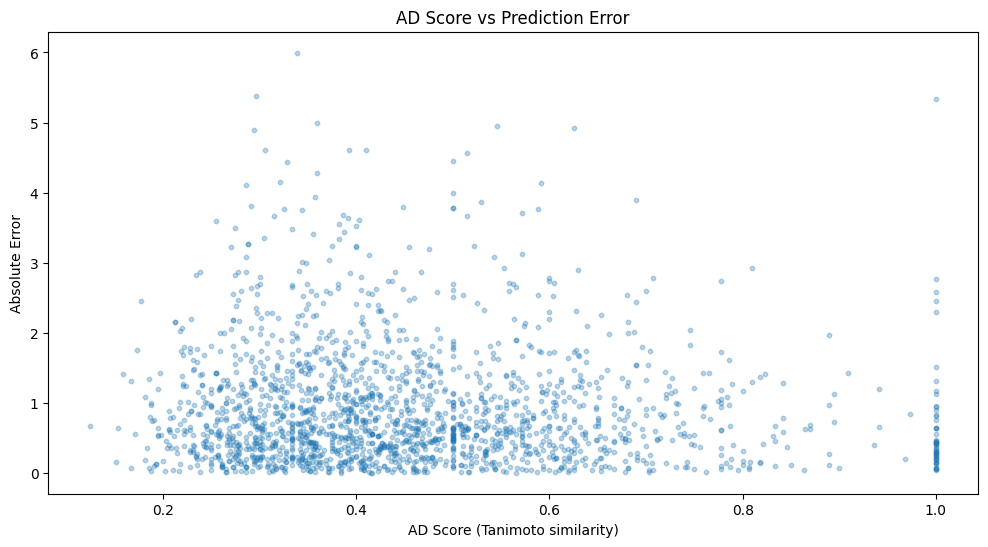

In [45]:
errors = []
ad_scores = []
for i in test_idx:
    mol = df['mol'].iloc[i]
    sim = ad_score(mol, train_fps)
    ad_scores.append(sim)

preds = stack.predict(x_test_sc)
errors = np.abs(y_test_sc.values - preds)
plt.figure(figsize=(12, 6))
plt.scatter(ad_scores, errors, alpha=0.3, s=10)
plt.xlabel('AD Score (Tanimoto similarity)')
plt.ylabel('Absolute Error')
plt.title('AD Score vs Prediction Error')
plt.show()

In [46]:
def predict_solubility(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return print("Invalid SMILES")
    
    sim = ad_score(mol, train_fps)
    conf = confidence_score_v2(mol, sim)
    
    desc_names_all = [d[0] for d in Descriptors._descList]
    calc_temp = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names_all)
    desc = np.array(calc_temp.CalcDescriptors(mol))
    desc = pd.DataFrame([desc], columns=desc_names_all)
    desc = desc[desc_df.columns]
    
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
    features = np.hstack([desc.values, fp.reshape(1, -1)])
    features = scaler.transform(features)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    features = np.clip(features, -1e6, 1e6)
    
    pred = stack.predict(features)[0]
    
    print(f"SMILES: {smiles}")
    print(f"Predicted Solubility: {pred:.2f} log(mol/L)")
    print(f"AD: {sim:.2f} — {ad_tier(sim)}")
    print(f"Confidence: {conf}")

In [ ]:
simple_test = {
    'Ethanol': 'CCO',
    'Methanol': 'CO',
    'Acetone': 'CC(=O)C',
    'Phenol': 'Oc1ccccc1',
    'Hexane': 'CCCCCC',
    'Toluene': 'Cc1ccccc1',
    'Urea': 'NC(=O)N',
    'Glycerol': 'OCC(O)CO',
    'Benzene': 'c1ccccc1',
    'Acetic acid': 'CC(=O)O',
}

complex_test = {
    'Artemisinin': 'O=C1OC2(OO3)CC(C)CCC3C2C(C)CC1',
    'PFOA': 'C(=O)(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F',
    'Triclosan': 'Oc1cc(Cl)ccc1Oc1ccc(Cl)cc1Cl',
    'Atrazine': 'CCNc1nc(Cl)nc(NC(C)C)n1',
    'Bisphenol A': 'CC(C)(c1ccc(O)cc1)c1ccc(O)cc1',
    'DDT': 'ClC(Cl)=C(c1ccc(Cl)cc1)c1ccc(Cl)cc1',
    'Capsaicin': 'COc1cc(CNC(=O)CCCC/C=C/C(C)C)ccc1O',
    'Cholesterol': 'CC(C)CCCC(C)C1CCC2C1(CCC1C2CC=C2CC(O)CCC21C)C',
    'Metformin': 'CN(C)C(=N)NC(=N)N',
    'Warfarin': 'CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O',
    'Ibuprofen': 'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
    'Paracetamol': 'CC(=O)Nc1ccc(O)cc1',
    'Salicylic acid': 'OC(=O)c1ccccc1O',
    'Naproxen': 'COc1ccc2cc(CC(C)C(=O)O)ccc2c1',
    'Diazepam': 'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21',
    'Ciprofloxacin': 'O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O',
    'Dexamethasone': 'CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O)C(=O)CO',
    'Estradiol': 'CC12CCC3c4ccc(O)cc4CCC3C1CCC2O',
    'Tamoxifen': 'CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1',
    'Ketoconazole': 'CC(=O)Oc1ccc(C2(Cn3ccnc3)OCC(O2)c2ccc(Cl)cc2Cl)cc1',
}

print("=== SIMPLE MOLECULES ===")
for name, smi in simple_test.items():
    print(f"--- {name} ---")
    predict_solubility(smi)
    print()

print("=== COMPLEX MOLECULES ===")
for name, smi in complex_test.items():
    print(f"--- {name} ---")
    predict_solubility(smi)
    print()
#this model is good for predicting solubility of complexe molecules, but not simple ones

=== SIMPLE MOLECULES ===
--- Ethanol ---
SMILES: CCO
Predicted Solubility: 0.84 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: 🚨 Possibly miscible — model unreliable

--- Methanol ---
SMILES: CO
Predicted Solubility: -0.81 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: 🚨 Possibly miscible — model unreliable

--- Acetone ---
SMILES: CC(=O)C
Predicted Solubility: 0.47 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: 🔶 Moderate confidence

--- Phenol ---
SMILES: Oc1ccccc1
Predicted Solubility: -1.49 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: ✅ High confidence

--- Hexane ---
SMILES: CCCCCC
Predicted Solubility: -3.95 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: ✅ High confidence

--- Toluene ---
SMILES: Cc1ccccc1
Predicted Solubility: -2.62 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: ✅ High confidence

--- Urea ---
SMILES: NC(=O)N
Predicted Solubility: 0.39 log(mol/L)
AD: 1.00 — ✅ in domain
Confidence: 🚨 Possibly miscible — model unreliable

--- Glycerol ---
SMILES: OCC(O)CO
Predicted So

In [49]:
import joblib

joblib.dump(stack, r'C:\Users\DELL\Desktop\P3\stack_model.pkl')
joblib.dump(scaler, r'C:\Users\DELL\Desktop\P3\scaler.pkl')
joblib.dump(list(desc_df.columns), r'C:\Users\DELL\Desktop\P3\desc_columns.pkl')
joblib.dump(train_fps, r'C:\Users\DELL\Desktop\P3\train_fps.pkl')
print("Saved!")

Saved!
